transfer 학습 구현

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Load the VGG16 model pre-trained on ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

In [3]:
# Create a new model and add the base model and new layers
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')  # Change to the number of classes you have
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [4]:
import os
from PIL import Image
import numpy as np

# Create directories if they don't exist
os.makedirs('sample_data/class_a', exist_ok=True)
os.makedirs('sample_data/class_b', exist_ok=True)

# Create 10 sample images for each class
for i in range(10):
    # Create a blank white image for class_a
    img = Image.fromarray(np.ones((224, 224, 3), dtype=np.uint8) * 255)
    img.save(f'sample_data/class_a/img_{i}.jpg')

    # Create a blank black image for class_b
    img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    img.save(f'sample_data/class_b/img_{i}.jpg')

print("Sample images created in 'sample_data/'")


Sample images created in 'sample_data/'


In [5]:
# Load and preprocess the dataset
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Verify if the generator has loaded images correctly
print(f"Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.")

# Train the model
if train_generator.samples > 0:
    model.fit(train_generator, epochs=10)

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.8786
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step - accuracy: 0.5000 - loss: 5.0176
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - accuracy: 0.5000 - loss: 3.1115
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step - accuracy: 0.5000 - loss: 0.4550
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy: 0.5000 - loss: 0.7867
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step - accuracy: 0.5000 - loss: 0.8514
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step - accuracy: 0.5000 - loss: 0.8675
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - accuracy: 0.5000 - loss: 0.8630
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step - accuracy: 0.5000 - loss: 0.8439
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step - accuracy: 0.5000 - loss: 0.8157


In [6]:
# Unfreeze the top layers of the base model 

for layer in base_model.layers[-4:]:
    layer.trainable = True 

# Compile the model again 
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) 

# Train the model again 
model.fit(train_generator, epochs=10) 

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7834
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step - accuracy: 0.5000 - loss: 0.6852
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 0.5000 - loss: 0.6810
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step - accuracy: 0.5000 - loss: 0.6595
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step - accuracy: 0.5000 - loss: 0.5945
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step - accuracy: 0.5000 - loss: 0.9010
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 0.5000 - loss: 1.6068
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step - accuracy: 0.5000 - loss: 0.7533
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.5000 - loss: 0.5665
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - accuracy: 0.5000 - loss: 0.6089


Found 16 images belonging to 2 classes.
Found 4 images belonging to 2 classes.
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step - accuracy: 0.5000 - loss: 0.6510 - val_accuracy: 0.5000 - val_loss: 0.4736
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - accuracy: 0.5000 - loss: 0.4736 - val_accuracy: 1.0000 - val_loss: 0.3161
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - accuracy: 1.0000 - loss: 0.3161 - val_accuracy: 1.0000 - val_loss: 0.1807
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step - accuracy: 1.0000 - loss: 0.1807 - val_accuracy: 1.0000 - val_loss: 0.0658
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step - accuracy: 1.0000 - loss: 0.0658 - val_accuracy: 1.0000 - val_loss: 0.0159
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 1.0000 - loss: 0.0159 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 634ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 7.9949e-04
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━

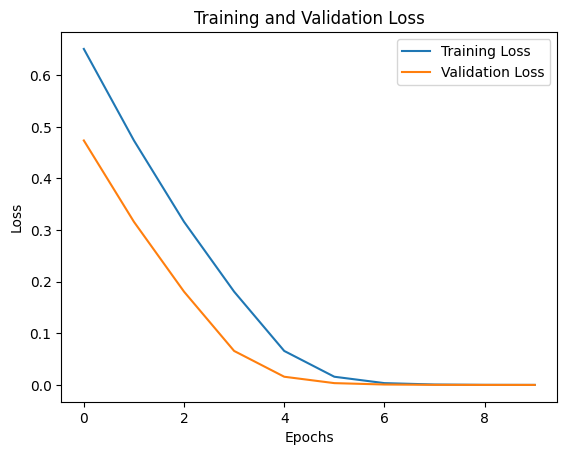

In [7]:
# Modify data generator to include validation data
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# Train the model with validation data
history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 5.3238e-06 - val_accuracy: 1.0000 - val_loss: 5.3210e-06
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step - accuracy: 1.0000 - loss: 5.3210e-06 - val_accuracy: 1.0000 - val_loss: 5.3183e-06
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - accuracy: 1.0000 - loss: 5.3183e-06 - val_accuracy: 1.0000 - val_loss: 5.3156e-06
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 1.0000 - loss: 5.3156e-06 - val_accuracy: 1.0000 - val_loss: 5.3128e-06
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step - accuracy: 1.0000 - loss: 5.3128e-06 - val_accuracy: 1.0000 - val_loss: 5.3101e-06
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - accuracy: 1.0000 - loss: 5.3101e-06 - val_accuracy: 1.0000 - val_loss: 5.3074e-06
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - accuracy: 1.0000 - loss: 5.3074e-06 - val_accuracy: 1.0000 - val_loss: 5.3047e-06
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 1.0

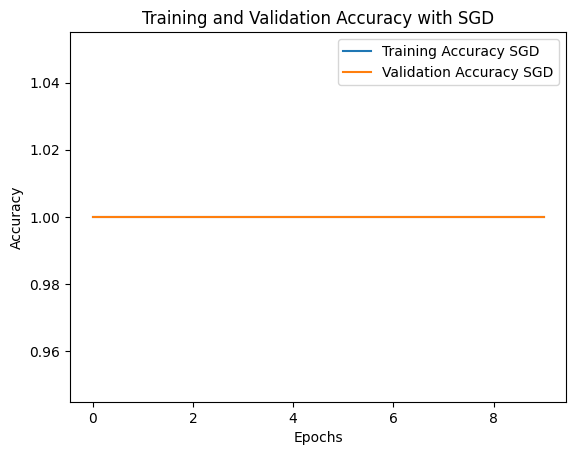

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 5.3238e-06 - val_accuracy: 1.0000 - val_loss: 4.5216e-06
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step - accuracy: 1.0000 - loss: 4.5216e-06 - val_accuracy: 1.0000 - val_loss: 3.9285e-06
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - accuracy: 1.0000 - loss: 3.9285e-06 - val_accuracy: 1.0000 - val_loss: 3.4719e-06
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - accuracy: 1.0000 - loss: 3.4719e-06 - val_accuracy: 1.0000 - val_loss: 3.1087e-06
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - accuracy: 1.0000 - loss: 3.1087e-06 - val_accuracy: 1.0000 - val_loss: 2.8134e-06
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step - accuracy: 1.0000 - loss: 2.8134e-06 - val_accuracy: 1.0000 - val_loss: 2.5684e-06
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step - accuracy: 1.0000 - loss: 2.5684e-06 - val_accuracy: 1.0000 - val_loss: 2.3621e-06
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step - accuracy: 1.0

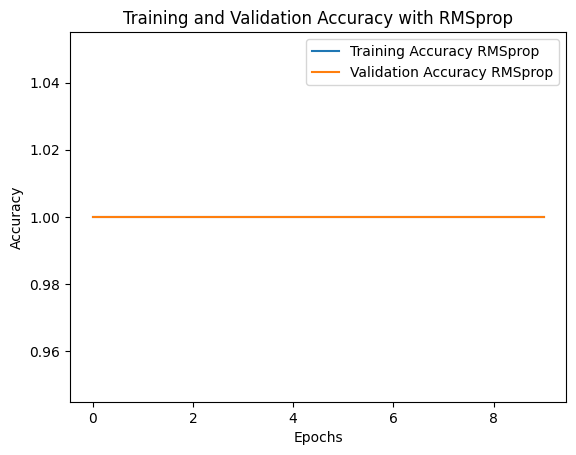

In [8]:
from tensorflow.keras.models import clone_model
import matplotlib.pyplot as plt

# Function to reset the model weights
def reset_model(model):
    # Clone the model to reset weights
    model_clone = clone_model(model)
    model_clone.set_weights(model.get_weights())
    return model_clone

# Prepare to reset the model for each optimizer test
initial_model = reset_model(model)  # Assume 'model' is the initial compiled model

# Experiment with SGD optimizer
sgd_model = reset_model(initial_model)  # Reset model
sgd_model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_sgd = sgd_model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot training and validation accuracy for SGD
plt.plot(history_sgd.history['accuracy'], label='Training Accuracy SGD')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy SGD')
plt.title('Training and Validation Accuracy with SGD')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Experiment with RMSprop optimizer
rmsprop_model = reset_model(initial_model)  # Reset model
rmsprop_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
history_rmsprop = rmsprop_model.fit(train_generator, epochs=10, validation_data=validation_generator)

# Plot training and validation accuracy for RMSprop
plt.plot(history_rmsprop.history['accuracy'], label='Training Accuracy RMSprop')
plt.plot(history_rmsprop.history['val_accuracy'], label='Validation Accuracy RMSprop')
plt.title('Training and Validation Accuracy with RMSprop')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [9]:
# Load and preprocess the test dataset
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'sample_data',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Evaluate the fine-tuned model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Found 20 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 1.0000 - loss: 5.3238e-06
Test Accuracy: 100.00%
Test Loss: 0.0000
